# Modelo de Análise de Risco de Crédito com Regressão Logística
### 📌 Estrutura
1. Carregamento e limpeza dos dados
2. Análise exploratória (EDA)
3. Modelagem — base, SMOTE, GridSearch, Pipeline
4. Avaliação — AUC-ROC, limiar, Precision-Recall
5. Interpretabilidade — coeficientes e SHAP
6. Conclusões de negócio
---


## 1. Carregamento e Limpeza dos Dados

In [ ]:
!pip install kagglehub -q

In [ ]:
# versões utilizadas neste notebook
# pra reproduzir o ambiente, descomente e execute:

# !pip install pandas==2.2.2 numpy==2.0.2 scikit-learn==1.6.1 \
#   imbalanced-learn==0.14.1 shap==0.51.0 kagglehub==0.3.13 \
#   statsmodels==0.14.6 matplotlib==3.10.0 seaborn==0.13.2 scipy==1.16.3

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score

In [ ]:
path = kagglehub.dataset_download("laotse/credit-risk-dataset")
csv_path = os.path.join(path, "credit_risk_dataset.csv")
df = pd.read_csv(csv_path)
df.head(10)

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [ ]:
# pra visualização da tabela ficar melhor, vamo renomear os nomes das colunas

df.rename(columns={'person_age':'idade', 'person_income' : 'renda', 'person_home_ownership' : 'propriedade_da_casa', 'person_emp_length' : 'tempo_de_trabalho', 'loan_intent' : 'intenção_do_empréstimo', 'loan_grade' : 'grau_do_empréstimo', 'loan_amnt' : 'montante_do_empréstimo', 'loan_int_rate' : 'taxa_de_juros', 'loan_status' : 'status_do_empréstimo', 'loan_percent_income' : 'renda_percentual_do_empréstimo', 'cb_person_default_on_file' : 'inadimplencia', 'cb_person_cred_hist_length' : 'tempo_de_crédito'}, inplace=True)
df.head(10)

,idade,renda,propriedade_da_casa,tempo_de_trabalho,intenção_do_empréstimo,grau_do_empréstimo,montante_do_empréstimo,taxa_de_juros,status_do_empréstimo,renda_percentual_do_empréstimo,inadimplencia,tempo_de_crédito
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


## 2. Análise Exploratória (EDA)

In [ ]:
# revisando os dados

# primeiro vamo dar uma olhada nas estatísticas descritivas:
df.describe()

,idade,renda,tempo_de_trabalho,montante_do_empréstimo,taxa_de_juros,status_do_empréstimo,renda_percentual_do_empréstimo,tempo_de_crédito
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


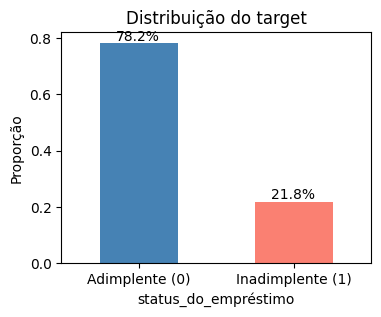

In [ ]:
# vamo visualizar a distribuição do target pra saber quantos % são inadimplentes

ax = df['status_do_empréstimo'].value_counts(normalize=True).plot(
    kind='bar', color=['steelblue', 'salmon'], figsize=(4, 3)
)
ax.set_xticklabels(['Adimplente (0)', 'Inadimplente (1)'], rotation=0)
ax.set_ylabel('Proporção')
ax.set_title('Distribuição do target')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + 0.1, p.get_height() + 0.01))
plt.show()

In [ ]:
# antes de tratar os dados inconsistentes, vamo ver se tem dado faltando
df.isnull().sum()  #-> tempo de trabalho e taxa de juros tem uma quantidadezinha boa de NaN

# pra tratar os NaN de tempo de trabalho, vamo substituir pela mediana
# tempo de trabalho é uma variável com distribuição assimétrica -> a mediana é mais robusta do que a média nesses casos
mediana_tempo_trabalho = df['tempo_de_trabalho'].median()
df['tempo_de_trabalho'] = df ['tempo_de_trabalho'].fillna (mediana_tempo_trabalho)
# pra tratar os NaN da taxa de juros, vamo substituir pela média (o segundo quartil e a média tão semelhantes, então tá ok)
media_taxa_de_juros = df ['taxa_de_juros'].mean()
df['taxa_de_juros'] = df ['taxa_de_juros'].fillna(media_taxa_de_juros)

df.isnull().sum() #-> todos os valores nulos foram tratados :)

,0
idade,0
renda,0
propriedade_da_casa,0
tempo_de_trabalho,0
intenção_do_empréstimo,0
grau_do_empréstimo,0
montante_do_empréstimo,0
taxa_de_juros,0
status_do_empréstimo,0
renda_percentual_do_empréstimo,0


Analisando as métricas descritivas:
- o valor máximo da 'idade' é 144. A mesma coisa acontece com o 'tempo de trabalho' que apresenta como valor máximo 123 anos.
- a gente tbm precisa se atentar ao fato de que a coluna 'status do empréstimo' deve ser preenchida apenas com 0 e 1. qqr coisa diferente disso, pode ser considerada um erro.

In [ ]:
# vamo tratar esses valores inconsistentes e substituir eles pela mediana

idade_min, idade_max = 0, 80  #-> aqi a gente delimita valores razoáveis
tempo_trabalho_min, tempo_trabalho_max = 0, 35

idade_inconsistente = (df ['idade'] < idade_min) | (df ['idade'] > idade_max)
tempo_trabalho_inconsistente = (df ['tempo_de_trabalho'] < tempo_trabalho_min) | (df ['tempo_de_trabalho'] > tempo_trabalho_max)

idade_mediana = int(round(df.loc[~idade_inconsistente, 'idade'].median()))  #-> aqi vamo calcular a mediana sem os valores inconsistentes
tempo_trabalho_mediana = df.loc [~tempo_trabalho_inconsistente, 'tempo_de_trabalho']. median()

df.loc [idade_inconsistente, 'idade'] = idade_mediana  #-> como a mediana ia sair um float, vamo arredondar pra não dar erro depois
df.loc [tempo_trabalho_inconsistente, 'tempo_de_trabalho'] = tempo_trabalho_mediana

Outliers identificados:
       idade    renda propriedade_da_casa  tempo_de_trabalho  \
15        23   500000            MORTGAGE                7.0   
33        25   306000                RENT                2.0   
34        26   300000            MORTGAGE               10.0   
42        26   300000            MORTGAGE               10.0   
43        23   300000                 OWN                1.0   
...      ...      ...                 ...                ...   
32497     63  1782000                RENT               13.0   
32543     52   720000            MORTGAGE                1.0   
32544     58   780000            MORTGAGE                7.0   
32546     60  1900000            MORTGAGE                5.0   
32551     58   780000            MORTGAGE                7.0   

      intenção_do_empréstimo grau_do_empréstimo  montante_do_empréstimo  \
15         DEBTCONSOLIDATION                  B                   30000   
33         DEBTCONSOLIDATION                  C          

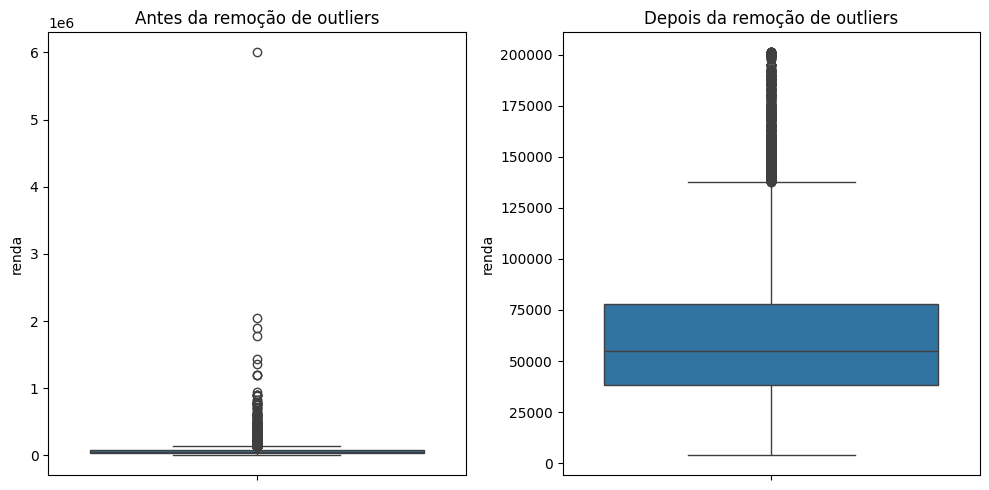

In [ ]:
# vamo tratar o outlier da renda utilizando o método do IQR

# Cálculo do IQR
Q1 = df['renda'].quantile(0.25)
Q3 = df['renda'].quantile(0.75)
IQR = Q3 - Q1

# Definição dos limites para detecção de outliers
# 1.5 seria o valor padrão mais aceito, mas seria restritivo demais pra renda, que naturalmente têm distribuição assimétrica
limite_inferior = Q1 - 3 * IQR   #-> então vamo usar 3 pra outliers extremos
limite_superior = Q3 + 3 * IQR

# Identificação de outliers
outliers = df[(df['renda'] < limite_inferior) | (df['renda'] > limite_superior)]
print("Outliers identificados:")
print(outliers)

df_cleaned = df [(df ['renda'] >= limite_inferior) & (df ['renda'] <= limite_superior)]

plt.figure (figsize=(10, 5))

plt.subplot (1, 2, 1)
sns.boxplot (y = df ['renda'])
plt.title ('Antes da remoção de outliers')

plt.subplot (1, 2, 2)
sns.boxplot (y = df_cleaned ['renda'])
plt.title ('Depois da remoção de outliers')

plt.tight_layout()
plt.show()

df = df_cleaned

In [ ]:
# sobre a coluna de status do empréstimo, vamo ver se foi preenchida com alguma coisa diferente de 0 e 1

print (df ['status_do_empréstimo'].unique())  #-> mostrou que só existem zeros e uns. então ok!

[1 0]


In [ ]:
# algumas variáveis são categóricas, o ideal é que elas sejam numéricas pra não dar erro
# vamo começar observando os valores únicos de cada variável

print (df ['propriedade_da_casa'].unique())
print (df ['intenção_do_empréstimo'].unique())
print (df ['grau_do_empréstimo'].unique())
print (df ['inadimplencia'].unique())

# a variável 'inadimplencia' é binária, então vamo usar o Label Encoding

df ['inadimplencia'] = df ['inadimplencia'].map ({'Y' : 1, 'N' : 0})

['RENT' 'OWN' 'MORTGAGE' 'OTHER']
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
['D' 'B' 'C' 'A' 'E' 'F' 'G']
['Y' 'N']


As outras variáveis categóricas possuem muitas categorias e a principal forma de lidar com elas (buscando convertê-las pra variáveis numéricas) é o One-Hot Encoding, que cria uma coluna separada pra cada categoria da variável. Optei por seguir analisando o comportamento das variáveis numéricas de forma isolada inicialmente, pra entender a contribuição de cada grupo de variáveis separadamente antes de combinar tudo num pipeline final.

(a gente até poderia fazer uma codificação ordinal, aplicando o LabelEncoder, mas essa abordagem é adequada pra categorias que possuem uma ordem lógica, natural. Como não é isso que acontece nessas variáveis em questão, não considerei apropriado)

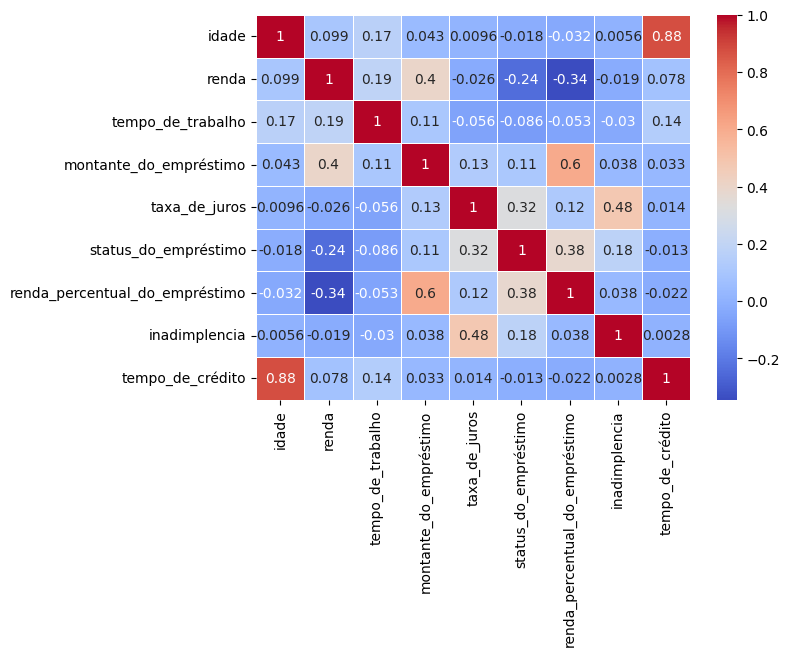

In [ ]:
# vamo fazer um heatmap pra checar a correlação entre as variáveis
# as variáveis categóricas vão ser excluídas já que a correlação de Pearson não se aplica a strings
# no pipeline de modelagem elas vão ser incorporadas via One_Hot Encoding

correlação = df.drop (columns = ['propriedade_da_casa', 'intenção_do_empréstimo', 'grau_do_empréstimo']).corr()
plt.figure (figsize = (7, 5))
sns.heatmap (correlação, annot = True, cmap = 'coolwarm', linewidths = 0.5)
plt.show()


- 'idade' e 'tempo_de_crédito' tão fortemente correlacionadas. Vamo tentar criar uma nova variável combinando as duas pra ajustar esse problema.

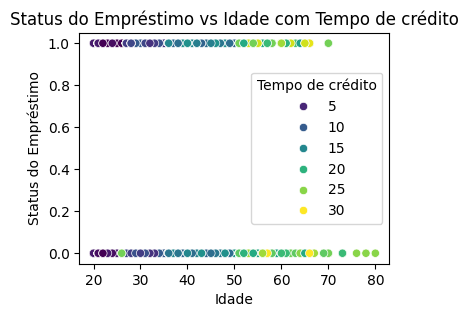

In [ ]:
# vamo fazer a interação entre 'idade' e 'tempo de crédito' pra ver se resolve o problema da alta correlação

df ['interacao_idade_tempo_credito'] = df ['idade'] * df ['tempo_de_crédito']

plt.figure (figsize = (4 ,3))
sns.scatterplot (x = 'idade', y = 'status_do_empréstimo', hue = 'tempo_de_crédito', palette = 'viridis', data = df)
plt.title ('Status do Empréstimo vs Idade com Tempo de crédito')
plt.xlabel ('Idade')
plt.ylabel ('Status do Empréstimo')
plt.legend (title = 'Tempo de crédito')
plt.show()

o gráfico da interação das variáveis não mostra nenhuma relação clara entre os envolvidos. salvo algumas exceções, quanto maior a idade, maior o tempo de crédito (o que faz total sentido). além disso, a gente consegue perceber que entre os adimplentes, o tempo de crédito pode ser ligeiramente maior (o que tbm faz total sentido, já que um histórico de crédito mais longo GERALMENTE indica maior experiência financeira).

-> vamo calcular a multicolinearidade com o VIF pra analisar o quanto essa multicolinearidade é preocupante.

In [ ]:
# vamo verificar a multicolinearidade com o VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# vamo excluir as colunas não numéricas e a variável alvo:
variaveis_independentes = df.drop (columns = ['propriedade_da_casa', 'intenção_do_empréstimo', 'grau_do_empréstimo', 'status_do_empréstimo', 'idade', 'tempo_de_crédito'])

variaveis_independentes = sm.add_constant (variaveis_independentes)  #-> add uma constante pra interceptação
vif = pd.DataFrame()
vif ["Variável"] = variaveis_independentes.columns
vif ["VIF"] = [variance_inflation_factor (variaveis_independentes.values, i) for i in range (variaveis_independentes.shape [1])]
print (vif)

                         Variável        VIF
0                           const  32.759223
1                           renda   3.306908
2               tempo_de_trabalho   1.058229
3          montante_do_empréstimo   4.596813
4                   taxa_de_juros   1.331207
5  renda_percentual_do_empréstimo   4.339501
6                   inadimplencia   1.296327
7   interacao_idade_tempo_credito   1.019834


- um VIF < 5 é normalmente aceitável. Então tudo ok com todas as variáveis.
- o VIF da interação entre a idade e o tempo de crédito pode mostrar como a interação não tá causando problemas de redundância no modelo, mas vamo confirmar se eles dois mais a interação entre eles não causa um problema no modelo.

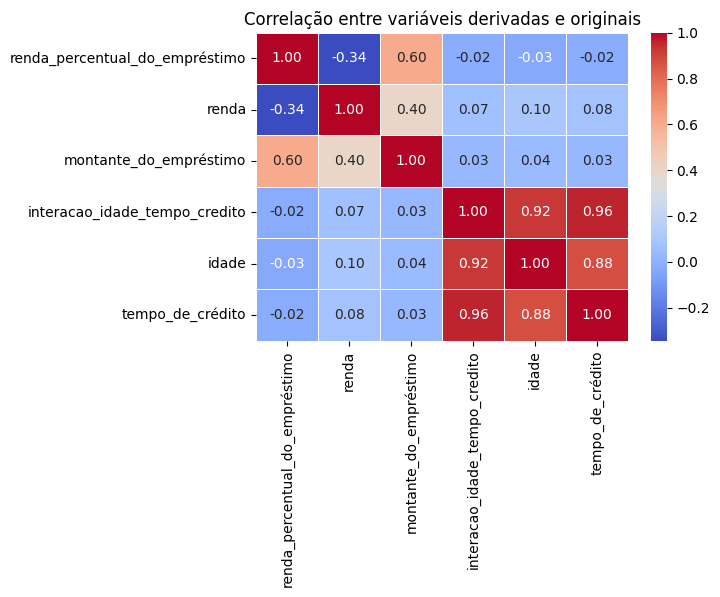

In [ ]:
# pra seguir com a avaliação de multicolinearidade, vamo usar a correlação de Pearson
# pra cobrir as variáveis derivadas que o VIF pode não capturar bem

plt.figure(figsize=(6, 4))
sns.heatmap(
    df[['renda_percentual_do_empréstimo', 'renda', 'montante_do_empréstimo', 'interacao_idade_tempo_credito', 'idade', 'tempo_de_crédito']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlação entre variáveis derivadas e originais')
plt.show()

- a idade, tempo de crédito e a interação entre elas duas mostra uma correlação altíssima (o que faz todo sentido, já que é o produto das duas), confirmando que as três não devem estar no mesmo modelo juntas.
- sendo assim, vamo remover idade e tempo de crédito e manter apenas a interação entre elas, já que ela já captura a informação das duas de forma combinada.
- por último: a renda percentual do empréstimo e o montante do empréstimo têm uma correlação moderada que, apesar de estar abaixo do thresold de 0.7, merece atenção (mas vamo seguir com ambas pq elas capturam dimensões diferentes).

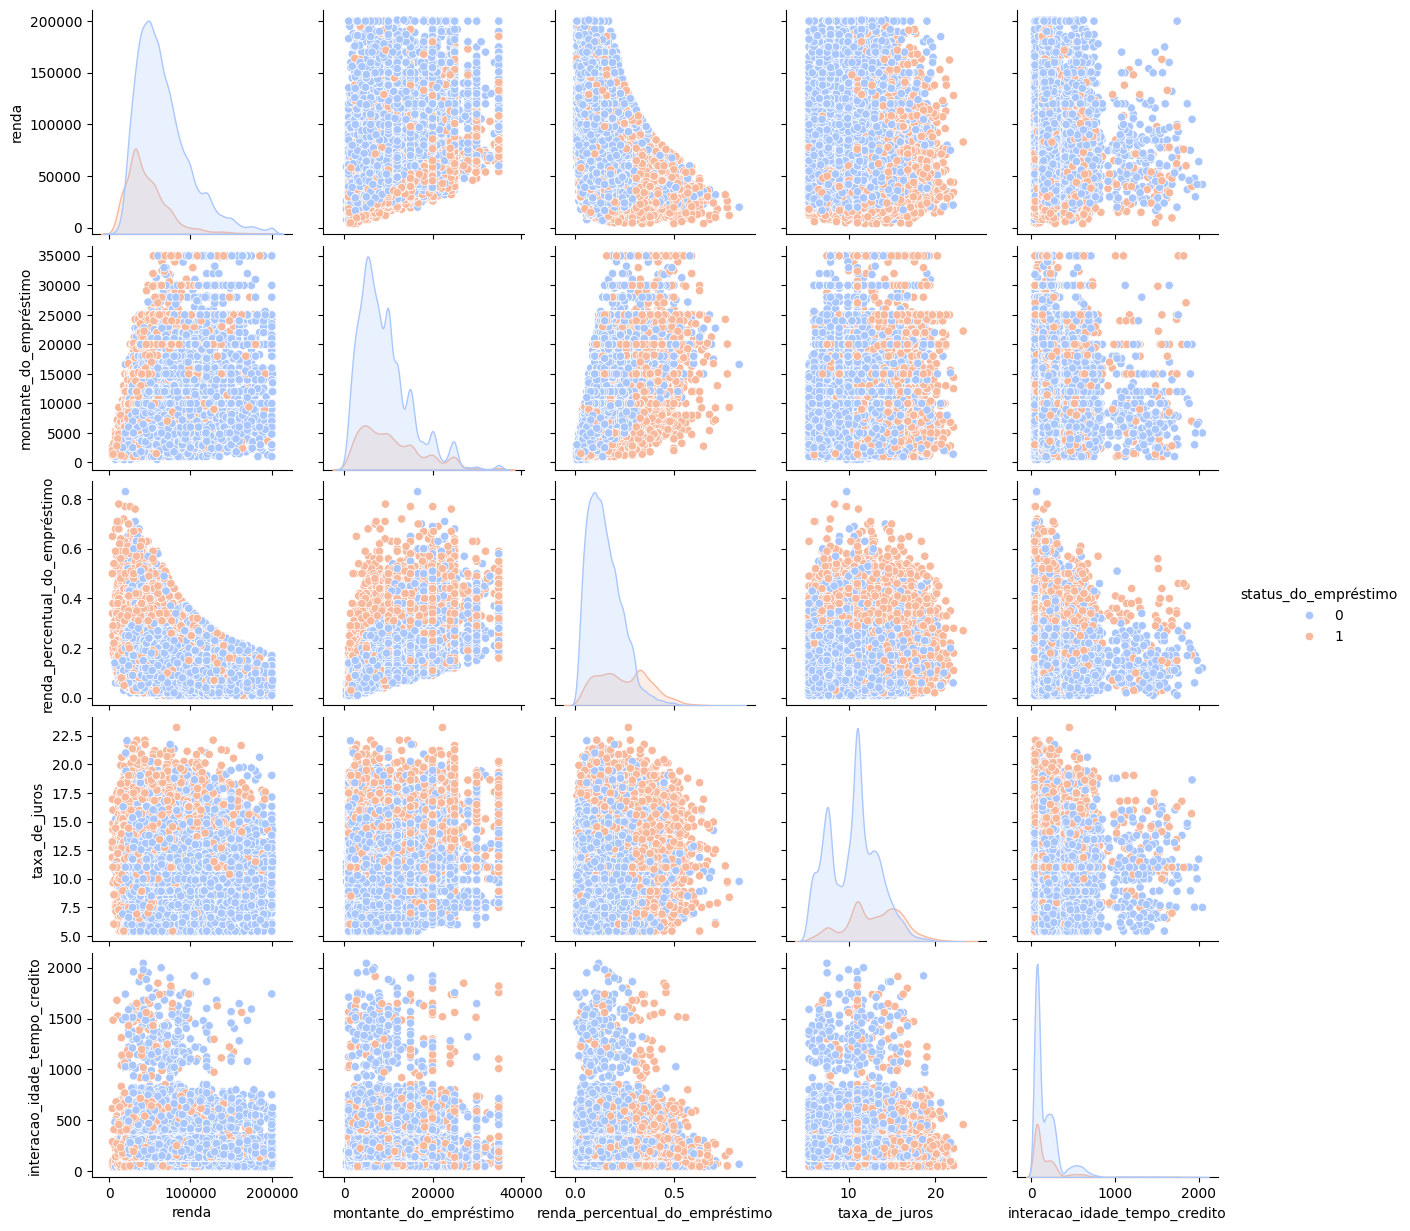

In [ ]:
# só pra gente dar uma última analisada nos dados
# status_do_empréstimo: 0 = adimplente; 1 = inadimplente

variaveis_importantes = ['renda', 'montante_do_empréstimo', 'renda_percentual_do_empréstimo', 'taxa_de_juros', 'interacao_idade_tempo_credito', 'status_do_empréstimo']
sns.pairplot (df [variaveis_importantes], hue = 'status_do_empréstimo', palette = 'coolwarm')
plt.show()

Pelo pairplot dá pra perceber algumas relações relevantes:
- qnt menor a renda, maior a concentração de inadimplentes. da mesma forma qnt maior a taxa de juros, maior a concentração de inadimplentes. inclusive: quanto maior a taxa de juros, maior o número de inadimplentes INCLUSIVE com rendas mais altas.
- empréstimos com taxas altas tendem ao default independente do valor do empréstimo, mas não mostra uma separação clara entre as classes. ou seja -> a taxa cobrada interfere mais do que o valor em si.
- a interação idade_tempo_de_crédito tbm mostra um padrão -> pessoas mais jovens com histórico curto concentram mais casos de inadimplência quando combinados com baixas rendas. esse efeito se dilui um pouco conforme a renda aumenta.
- a região de alta renda + baixa renda percentual do empréstimo é dominada pelos adimplentes (o que faz muito sentido já que quem tem renda alta tende a comprometer menos percentual com o empréstimo).
- tbm dá pra concluir que comprometer muita renda com o empréstimo é um risco por si só, independente da taxa de juros, já que os inadimplentes aparecem espalhados por toda região de altas percentuais independente da taxa.
- tbm dá pra verificar que o outlier da renda foi realmente tratado na etapa de limpeza pelo IQR.

## 3. Modelagem

In [ ]:
# agora a gente já pode ir pro treinamento do modelo
# primeiro vamo definir X e Y:

X = df.drop (columns = ['propriedade_da_casa', 'intenção_do_empréstimo', 'grau_do_empréstimo', 'status_do_empréstimo', 'idade', 'tempo_de_crédito'])
Y = df ['status_do_empréstimo']

# agora vamo dividir os dados em treino e teste:
# vamo incluir um max_iter=1000 pra garantir convergência do solver com esse volume de features
X_treino, X_teste, Y_treino, Y_teste = train_test_split (X, Y, test_size = 0.2, random_state = 42)

# depois, criar e testar o modelo:
modelo = LogisticRegression(random_state = 42, max_iter=1000) #-> vamo incluir o random_state = 42 aqui pra garantir reprodutibilidade
modelo.fit (X_treino, Y_treino)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# pra fazer as previsões do modelo:
y_pred = modelo.predict (X_teste)

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      5047
           1       0.69      0.42      0.52      1383

    accuracy                           0.83      6430
   macro avg       0.77      0.68      0.71      6430
weighted avg       0.82      0.83      0.82      6430

AUC-ROC: 0.8358


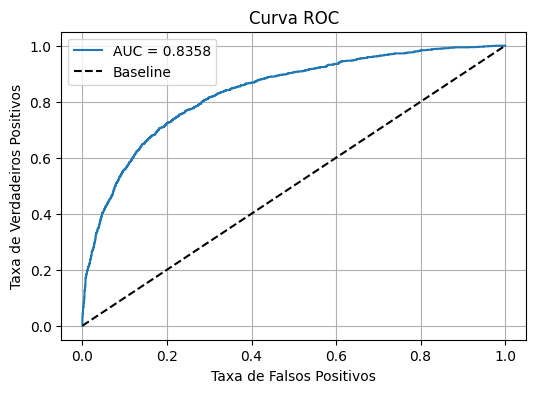

In [ ]:
# vamo avaliar o desempenho do modelo:

# as métricas reais usadas por times de risco em bancos são AUC-ROC e KS Statistic
# além disso, nosso dataset é desbalanceado, então acurácia e precisão são métricas ruins de serem analisadas

from sklearn.metrics import roc_auc_score, roc_curve

relatorio = classification_report (Y_teste, y_pred)
print (relatorio)

probabilidades = modelo.predict_proba(X_teste)[:, 1]
auc = roc_auc_score(Y_teste, probabilidades)
print(f"AUC-ROC: {auc:.4f}")

fpr, tpr, _ = roc_curve(Y_teste, probabilidades)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

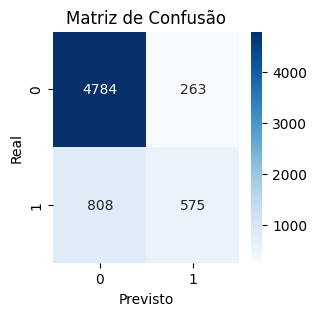

In [ ]:
# analisando a matriz de confusão:

matriz_de_confusao = confusion_matrix (Y_teste, y_pred)

plt.figure(figsize=(3, 3))
sns.heatmap(matriz_de_confusao, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

se a gente levar em consideração que:
- a baseline representa um modelo aleatório que chuta as classes, sem nenhum aprendizado, acertando 50% na sorte;
- e que um valor de AUC (que diz quanto o modelo consegue distinguir corretamente um inadimplente de um adimplente) entre 0.8 e 0.9 é ótimo;

dá pra concluir que nosso modelo - com AUC de 0.8358 e com a curva ROC se afastando bem da diagonal baseline - tem poder preditivo real

.

além disso, o modelo é bom ao identificar os casos de adimplência (precision 0.86, recall 0.95) mas tem dificuldade com os inadimplentes (precision 0.69, recall 0.42). isso se reflete na matriz de confusão — de 1383 inadimplentes reais, 808 foram classificados incorretamente como adimplentes.

Esse padrão é esperado em datasets desbalanceados (5047 adimplentes vs 1383 inadimplentes), então vamo balancear as classes pra analisar o impacto.


              precision    recall  f1-score   support

           0       0.91      0.77      0.83      5047
           1       0.46      0.72      0.56      1383

    accuracy                           0.76      6430
   macro avg       0.69      0.75      0.70      6430
weighted avg       0.81      0.76      0.78      6430

AUC-ROC: 0.8204


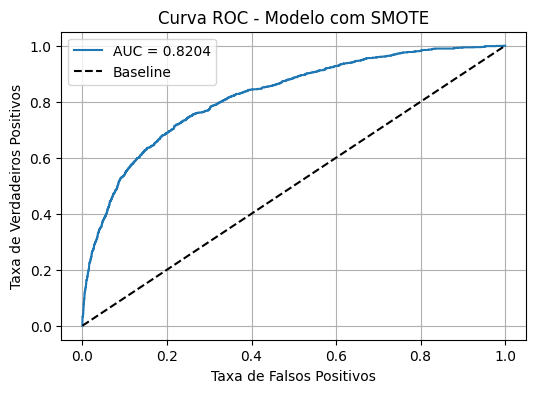

In [ ]:
# vamo balancear os dados reamostrando as classes
# pra isso, vamo usar oversampling com SMOTE que vai, basicamente, gerar novos exemplos pra classe minoritária

from imblearn.over_sampling import SMOTE

smote = SMOTE (random_state = 42)  #-> aumentar a classe minoritária
X_res, Y_res = smote.fit_resample (X_treino, Y_treino)
modelo_smote = LogisticRegression(random_state=42, max_iter=1000)  #-> treinar o modelo com os dados reamostrados
modelo_smote.fit (X_res, Y_res)
y_pred_smote = modelo_smote.predict (X_teste)  #-> fazer as previsões

relatorio_smote = classification_report (Y_teste, y_pred_smote)  #-> e reavaliar o modelo
print (relatorio_smote)

probabilidades_smote = modelo_smote.predict_proba(X_teste)[:, 1]
auc_smote = roc_auc_score(Y_teste, probabilidades_smote)
fpr_smote, tpr_smote, _ = roc_curve(Y_teste, probabilidades_smote)
print(f"AUC-ROC: {auc_smote:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(fpr_smote, tpr_smote, label=f'AUC = {auc_smote:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Modelo com SMOTE')
plt.legend()
plt.grid(True)
plt.show()


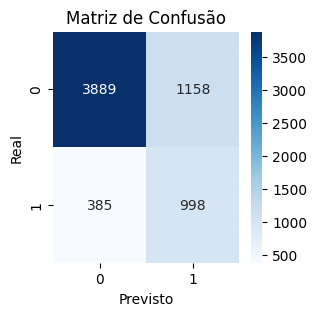

In [ ]:
# e analisando a matriz de confusão de novo:

matriz_smote = confusion_matrix (Y_teste, y_pred_smote)

plt.figure(figsize=(3, 3))
sns.heatmap(matriz_smote, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

- o SMOTE aumentou o recall dos inadimplentes (0.42 -> 0.72), representando uma melhoria na identifiação dessa classe. Mas isso aconteceu às custas da precisão, que diminuiu de 0.69 pra 0.46, indicando que o modelo tá gerando vários falsos positivos. A matriz de confusão mostra mais de 1000 classificações errôneas dos adimplentes.
- resumindo: péssima abordagem. o modelo passou a gerar mais falsos positivos sem ganho real no poder discriminatório.
- o SMOTE trabalha criando dados sintéticos pra equilibrar as classes fisicamente. então vamo tentar uma nova abordagem: usar o class_weight='balanced' (pra preservar os dados reais e ajustar o aprendizado pra reequilibrar a importância de cada erro) dentro do GridSearch pra encontrar os melhores hiperparâmetros já considerando o desbalanceamento.

In [ ]:
# vamo tentar um ajuste de hiperparâmetros com cross-validation

from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10, 100], 'solver': ['lbfgs']}

modelo_grid = LogisticRegression (random_state=42, max_iter=1000, class_weight='balanced')
grid = GridSearchCV (modelo_grid, param_grid, cv = 5, scoring = 'roc_auc')
grid.fit (X_treino, Y_treino)

melhor_modelo = grid.best_estimator_
y_pred_grid = melhor_modelo.predict (X_teste)

print(f"Melhores parâmetros: {grid.best_params_}")
print(classification_report (Y_teste, y_pred_grid))

probabilidades_grid = melhor_modelo.predict_proba(X_teste)[:, 1]
auc_grid = roc_auc_score(Y_teste, probabilidades_grid)
fpr_grid, tpr_grid, _ = roc_curve(Y_teste, probabilidades_grid)
print(f"AUC-ROC: {auc_grid:.4f}")

Melhores parâmetros: {'C': 100, 'solver': 'lbfgs'}
              precision    recall  f1-score   support

           0       0.92      0.76      0.83      5047
           1       0.46      0.76      0.57      1383

    accuracy                           0.76      6430
   macro avg       0.69      0.76      0.70      6430
weighted avg       0.82      0.76      0.78      6430

AUC-ROC: 0.8365


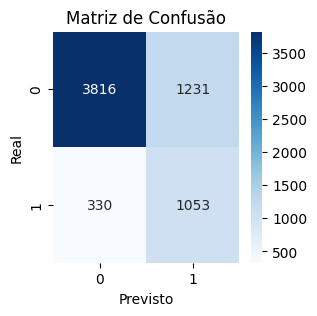

In [ ]:
# vamo analisar a nova matriz de confusão pra seguir com o padrão de comparações:

matriz_grid = confusion_matrix(Y_teste, y_pred_grid)

plt.figure(figsize=(3, 3))
sns.heatmap(matriz_grid, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()


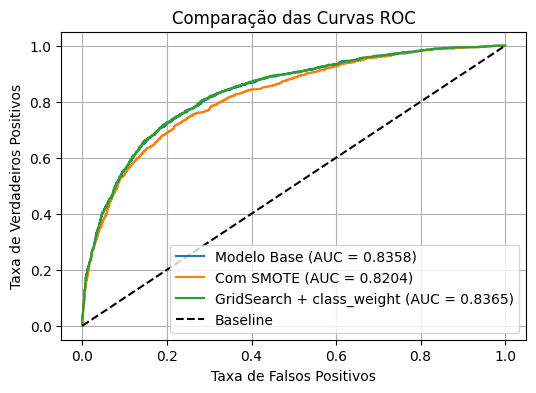

In [ ]:
# pra entender a evolução do modelo até aqui, vamo comparar a curva ROC dos três modelos:

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Modelo Base (AUC = {auc:.4f})')
plt.plot(fpr_smote, tpr_smote, label=f'Com SMOTE (AUC = {auc_smote:.4f})')
plt.plot(fpr_grid, tpr_grid, label=f'GridSearch + class_weight (AUC = {auc_grid:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Comparação das Curvas ROC')
plt.legend()
plt.grid(True)
plt.show()

- os três modelos têm um AUC-ROC similar (variando entre 0.82 e 0.84), indicando que o poder descriminatório é consistente.
- o desafio continua sendo o recall dos inadimplentes.
- o modelo base prioriza a precisão (com 0.69), enquanto os outros dois priorizam o recall (com 0.76) às custas da precisão (com 0.46). a escolha entre eles vai depender da estratégia de risco da instituição.
- ou seja: priorizando a precisão (como o modelo base), a gente aprova mais cliente mas deixa passar mais inadimplente, seguindo um caminho mais agressivo; do outro lado, priorizando o recall, a gente erra menos inadimplentes reais, mas rejeita mais bons clientes, resultando em uma abordagem mais conservadora.

                         Variável  Coeficiente    Odds Ratio
4  renda_percentual_do_empréstimo    10.383828  32332.480030
3                   taxa_de_juros     0.290494      1.337087
5                   inadimplencia     0.213658      1.238199
1               tempo_de_trabalho    -0.017033      0.983111
2          montante_do_empréstimo    -0.000067      0.999933
6   interacao_idade_tempo_credito     0.000008      1.000008
0                           renda    -0.000006      0.999994


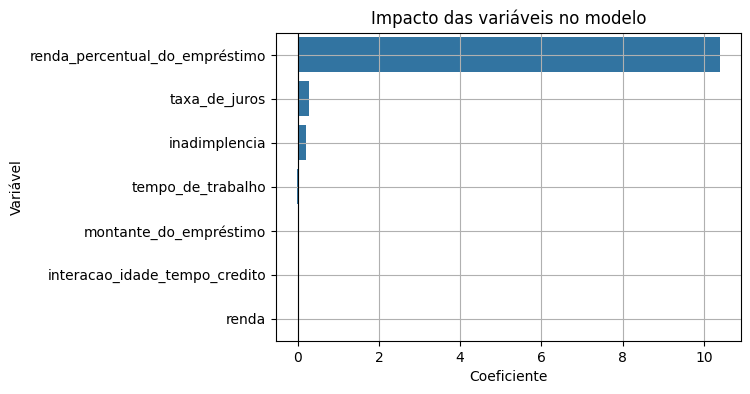

In [ ]:
# vamo analisar os coeficientes do modelo pra entender o impacto de cada uma na variável alvo
# vamo usar o melhor_modelo que a gente achou com o GridSearch

coeficientes = melhor_modelo.coef_[0]
variaveis = X_treino.columns
coeficientes_df = pd.DataFrame ({'Variável' : variaveis, 'Coeficiente' : coeficientes, 'Odds Ratio' : np.exp (coeficientes)})

coeficientes_df = coeficientes_df.reindex (coeficientes_df.Coeficiente.abs().sort_values (ascending = False).index)
print (coeficientes_df)

plt.figure(figsize=(6, 4))
sns.barplot(data=coeficientes_df, x='Coeficiente', y='Variável')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Impacto das variáveis no modelo')
plt.grid(True)
plt.show()

- tempo de trabalho retorna um coeficiente negativo. a gente pode concluir com isso que quanto maior a estabilidade profissional, menor o risco;
- taxa de juros e inadimplencia no histórico de crédito retornam coeficientes positivos. faz sentido que quem já teve default antes, tem chance de ter novamente, explicando o coeficiente da inadimplencia. já sobre a taxa de juros, o resultado já era esperado pelo que a gente viu no pairplot: quanto maior a taxa, maior o risco;
- a variável mais impactante é a renda percentual do empréstimo com um coeficiente de 10.38, o que significa que comprometer uma grande parte da renda com o empréstimo é o principal sinal de risco.
- apesar disso, dá pra perceber que esse coeficiente tá inflado, alto demais. é normal que isso aconteça já que as variáveis não foram normalizadas (e variáveis não normalizadas se comportam exatamente assim em modelos de regressão logística).


- não normalizar as variáveis isoladamente antes de treinar o modelo foi uma decisão tomada pra evitar leakage dos dados, mas não normalizar resulta realmente em coeficientes inflados, já que ao normalizar todas as variáveis numéricas para a mesma escala, os coeficientes se tornam comparáveis entre si e a interpretação passa a refletir o impacto real do peso de cada variável no modelo;
- além disso, até aqui o modelo foi explorado usando apenas as variáveis numéricas pra entender a contribuição de cada uma isoladamente. então o próximo passo vai ser incorporar as variáveis categóricas (propriedade_da_casa e intenção_do_empréstimo) ao modelo.
- vamo resolver essas duas questões usando um Pipeline do scikit-learn que encadeia o pré-processamento e o modelo numa sequência única. Dessa forma, vamo garantir que a normalização seja aplicada separadamente em treino e teste, eliminando o risco de vazamento de dados, ao mesmo tempo que a gente incorpora as variáveis categóricas via One-Hot Encoding.

In [ ]:
# vamo transformar as variáveis categóricas em numéricas usando o One-Hot-Encoding

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

colunas_categoricas = ['propriedade_da_casa', 'intenção_do_empréstimo', 'grau_do_empréstimo']
colunas_numericas = ['taxa_de_juros', 'montante_do_empréstimo', 'tempo_de_trabalho', 'renda_percentual_do_empréstimo', 'renda', 'inadimplencia', 'interacao_idade_tempo_credito']
X = df.drop ('status_do_empréstimo', axis = 1)
Y = df ['status_do_empréstimo']


preprocessor = ColumnTransformer (transformers = [('num', StandardScaler(), colunas_numericas), ('cat', OneHotEncoder(sparse_output=False, drop = 'first'), colunas_categoricas)], remainder = 'drop')
#-> o drop = first taí pra evitar colinearidade
pipeline = Pipeline (steps = [('preprocessor', preprocessor), ('classifier', LogisticRegression (max_iter=1000, random_state=42, class_weight='balanced'))])

X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, Y, test_size=0.2, random_state=42)
pipeline.fit(X_treino, Y_treino)

y_pred_pipeline = pipeline.predict(X_teste)
print(classification_report(Y_teste, y_pred_pipeline))

probabilidades_pipeline = pipeline.predict_proba(X_teste)[:, 1]
auc_pipeline = roc_auc_score(Y_teste, probabilidades_pipeline)
fpr_pipeline, tpr_pipeline, _ = roc_curve(Y_teste, probabilidades_pipeline)
print(f"AUC-ROC: {auc_pipeline:.4f}")


              precision    recall  f1-score   support

           0       0.93      0.82      0.87      5047
           1       0.54      0.79      0.64      1383

    accuracy                           0.81      6430
   macro avg       0.74      0.80      0.76      6430
weighted avg       0.85      0.81      0.82      6430

AUC-ROC: 0.8761


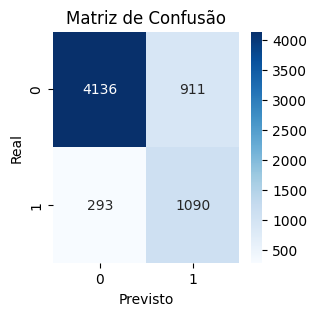

In [ ]:
# vamo analisar a nova matriz de confusão pra seguir com o padrão de comparações:

matriz_pipeline = confusion_matrix(Y_teste, y_pred_pipeline)

plt.figure(figsize=(3, 3))
sns.heatmap(matriz_pipeline, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

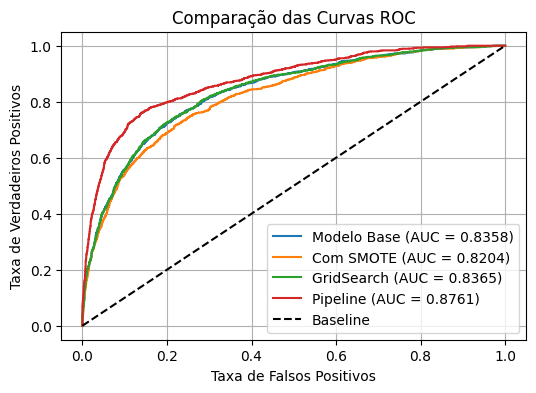

In [ ]:
# vamo plotar a curva comparativa dos 4 modelos pra acompanhar a evolução:

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Modelo Base (AUC = {auc:.4f})')
plt.plot(fpr_smote, tpr_smote, label=f'Com SMOTE (AUC = {auc_smote:.4f})')
plt.plot(fpr_grid, tpr_grid, label=f'GridSearch (AUC = {auc_grid:.4f})')
plt.plot(fpr_pipeline, tpr_pipeline, label=f'Pipeline (AUC = {auc_pipeline:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Comparação das Curvas ROC')
plt.legend()
plt.grid(True)
plt.show()

- dá pra concluir que incluir as variáveis categóricas e normalizar corretamente todas as variáveis dentro do Pipeline resultou em uma melhora real no poder preditivo do modelo. AUC-ROC subiu de 0.8358 pra 0.8761, o que é bem significativo!
- o modelo com Pipeline tbm teve o melhor equilíbrio entre recall e precisão pra os inadimplentes.

                                       Variável  Coeficiente  Odds Ratio
20                    cat__grau_do_empréstimo_G     4.230572   68.756564
19                    cat__grau_do_empréstimo_F     2.903707   18.241649
18                    cat__grau_do_empréstimo_E     2.610183   13.601546
17                    cat__grau_do_empréstimo_D     2.372542   10.724618
8                  cat__propriedade_da_casa_OWN    -1.595721    0.202762
3           num__renda_percentual_do_empréstimo     1.301186    3.673653
14          cat__intenção_do_empréstimo_VENTURE    -1.042225    0.352669
10        cat__intenção_do_empréstimo_EDUCATION    -0.698796    0.497184
9                 cat__propriedade_da_casa_RENT     0.610891    1.842073
1                   num__montante_do_empréstimo    -0.592229    0.553093
13         cat__intenção_do_empréstimo_PERSONAL    -0.438385    0.645078
16                    cat__grau_do_empréstimo_C     0.362953    1.437568
7                cat__propriedade_da_casa_OTHER    

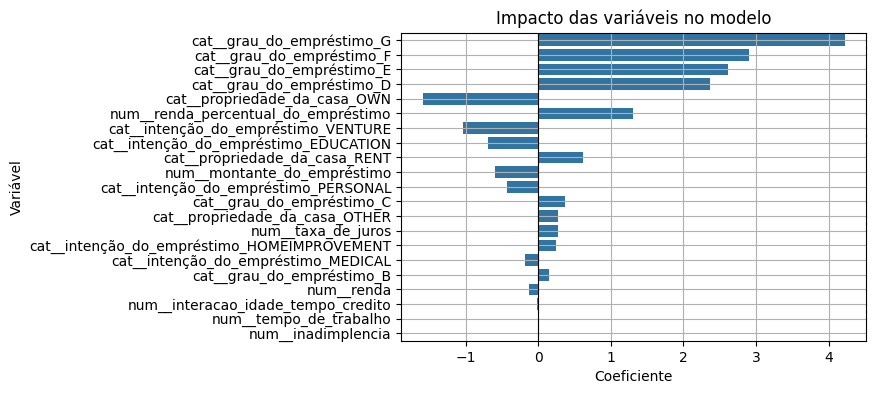

In [ ]:
# agora que o Pipeline normalizou tudo, vamo rever os coeficientes

coeficientes_pipeline = pipeline.named_steps['classifier'].coef_[0]
variaveis_pipeline = (pipeline.named_steps['preprocessor'].get_feature_names_out())
coeficientes_pipeline_df = pd.DataFrame({'Variável': variaveis_pipeline, 'Coeficiente': coeficientes_pipeline, 'Odds Ratio': np.exp(coeficientes_pipeline)})

coeficientes_pipeline_df = coeficientes_pipeline_df.reindex (coeficientes_pipeline_df.Coeficiente.abs().sort_values(ascending=False).index)
print (coeficientes_pipeline_df)

plt.figure(figsize=(6, 4))
sns.barplot(data=coeficientes_pipeline_df, x='Coeficiente', y='Variável')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Impacto das variáveis no modelo')
plt.grid(True)
plt.show()

- agora que as variáveis tão normalizadas e com variáveis categóricas inclusas, os coeficientes se mostram bem mais coerentes e com novas análises pertinentes:
- o grau do empréstimo é o próprio rating de risco atribuído pela instituição, então ele captura diretamente a probabilidade de default, então faz todo sentido que os graus tenham os maiores coeficientes e que eles sejam positivos. G -> maior risco -> coef de 4.23, por exemplo;
- propriedade da casa (OWN) tbm aparece com um coeficiente alto e negativo, indicando que quem tem casa própria tem menor risco. isso faz sentido se a gente considerar esse um indicativo de estabilidade financeira;
- a renda percentual do empréstimo continua sendo bem relevante (agora em uma escala comparável), confirmando que comprometer muita renda com uma dívida é um sinal de risco real;
- por último, o coeficiente da inadimplencia histórica ficou praticamente irrelevante quando o grau do empréstimo entrou no modelo. dá pra concluir que o grau já captura o histórico de crédito de forma mais completa.


## 4. Avaliação

- seguindo o padrão, a regressão logística classifica como 1 as previsões que têm probabilidade maior do que 0.5. ou seja: a gente considera o limiar de decisão padrão 0.5.
- vamo fazer uma análise de sensibilidade pra entender como precisão, recall e F1 se comportam ao longo do espectro dos limiares em relação à classe 1 (inadimplentes)

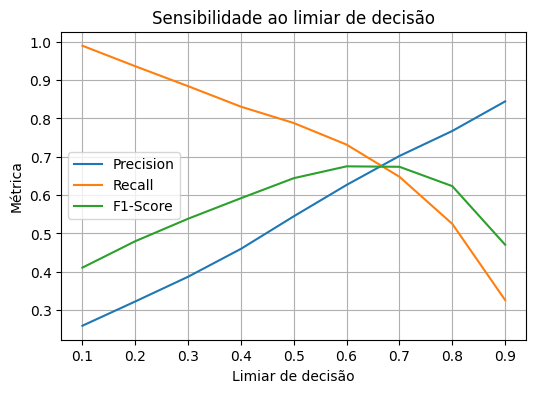

In [ ]:
# vamo fazer a análise de sensibilidade ao limiar de decisão

from sklearn.metrics import precision_recall_fscore_support

probs = pipeline.predict_proba (X_teste) [:, 1]
limiares = np.arange (0.1, 1, 0.1)  #-> variando de 0.1 a 0.9

# diferente do que a gente usou no modelo (AUC-ROC é independente do threshold), aqi vamo usar as métricas que dependem do limiar
precisions = []
recalls = []
f1_scores = []

for limiar in limiares:
  y_pred_limiar = (probs >= limiar).astype (int)
  precision, recall, f1, _ = precision_recall_fscore_support (Y_teste, y_pred_limiar, average = 'binary')
  precisions.append (precision)
  recalls.append (recall)
  f1_scores.append (f1)

plt.figure (figsize = (6, 4))
plt.plot (limiares, precisions, label = 'Precision')
plt.plot (limiares, recalls, label = 'Recall')
plt.plot (limiares, f1_scores, label = 'F1-Score')
plt.xlabel ('Limiar de decisão')
plt.ylabel ('Métrica')
plt.title ('Sensibilidade ao limiar de decisão')
plt.legend()
plt.grid (True)
plt.show()

- o F1 é, basicamente, a média harmônica entre precisão e recall. então, o pico de F1 já representa o ponto de equilíbrio entre os dois. dá pra visualizar que o F1 atinge esse pico entre 0.6 e 0.7.

sendo assim, temos:
- com o limiar até 0.5 -> recall alto e precisão baixa. o modelo captura quase todos os inadimplentes reais, mas aprova menos bons clientes. isso serve pra um perfil ultra-conservador/conservador;
- limiar entre 0.6 e 0.7 -> é o melhor equilíbrio entre as métricas. isso serve pra um perfil moderado;
- limiar acima de 0.7 -> a precisão vai sunbindo, mas o recall cai  bastante. o modelo só vai classificar como inadimplente se ele tiver muuuita certeza, deixando passar muitos inadimplentes reais. isso serve pra um modelo muito permissivo.

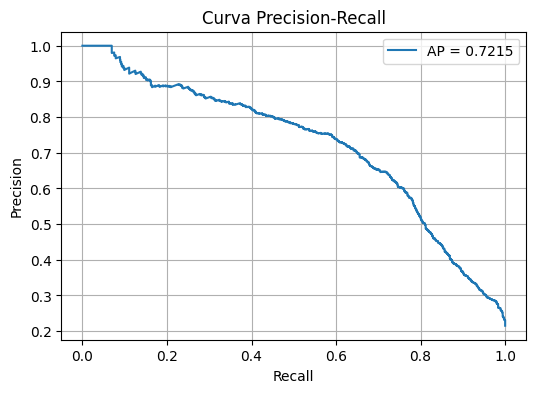

In [ ]:
# vamo incluir uma curva Precision-Recall pra mostrar o trade-off direto entre as duas métricas ao longo de todos os limiares

from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, _ = precision_recall_curve(Y_teste, probs)
ap = average_precision_score(Y_teste, probs)

plt.figure(figsize=(6, 4))
plt.plot(recall_curve, precision_curve, label=f'AP = {ap:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid(True)
plt.show()

antes de tirar conclusões sobre o resultado, vale entender o que:
- em uma distribuição balanceada (50/50), um classificador aleatório teria AP de 0.5. no caso do nosso dataset, aproximadamente 22% dos casos são inadimplentes e 78% adimplentes (ou seja: 22/78). nessa distribuição, um classificador aleatório teria AP próximo de 0.22, já que a chance de acertar um inadimplente ao acaso é baixa.

então, como nosso AP de 0.72 não tá sendo comparado com o 0.5 como baseline, e sim com o 0.22, a distância real entre esse modelo e o acaso é bem maior do que parece à primeira vista.

o formato da curva tbm traz bons insights:
- a curva começa alta e vai decaindo de forma gradual e suave. ou seja: o modelo é bem preciso quando tá confiante, mas vai perdendo confiança progressivamente conforme tenta capturar mais inadimplentes. ele não tem um ponto de colapso abrupto, o que é um indicativo de que o modelo não é fraco;
- a queda mais acentuada começa após recall 0.7. ou seja: a partir daqui o modelo começa a forçar classificações, gerando muito mais falsos positivos pra capturar os inadimplentes que restaram.



In [ ]:
# vamo aprofundar a investigação do limiar exato do pico do F1
# pra isso, vamo varrer de 0.55 a 0.75 com precisão de 0.01

from sklearn.metrics import f1_score

limiares_finos = np.arange(0.55, 0.75, 0.01)
f1_scores_finos = []

for limiar in limiares_finos:
    y_pred_lim = (probs >= limiar).astype(int)
    f1 = f1_score(Y_teste, y_pred_lim)
    f1_scores_finos.append(f1)

limiar_otimo = limiares_finos[np.argmax(f1_scores_finos)]
y_pred_limiar_otimo = (probs >= limiar_otimo).astype(int)

print(f"Limiar ótimo: {limiar_otimo:.2f}")
print(f"F1 máximo: {max(f1_scores_finos):.4f}")

Limiar ótimo: 0.62
F1 máximo: 0.6798


pronto. agora tá claro que o limiar ótimo pra um perfil moderado é de 0.62. ele vai nos garantir um F1 de 0.68. isso quer dizer, basicamente:
- o modelo vai classificar como inadimplente qualquer cliente cuja probabilidade de default seja maior ou igual a 62%;
- e pra esse valor de thresold (0.62), vai apresentar equilíbrio entre precisão e recall de quase 68%.

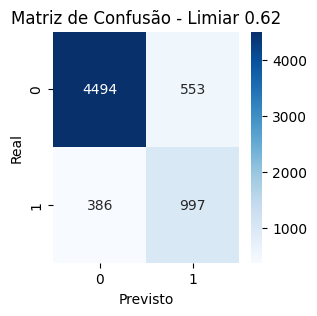

In [ ]:
matriz_limiar = confusion_matrix(Y_teste, y_pred_limiar_otimo)

plt.figure(figsize=(3, 3))
sns.heatmap(matriz_limiar, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title(f'Matriz de Confusão - Limiar {limiar_otimo:.2f}')
plt.show()

importante destacar que nesse ponto, todas as decisões a serem tomadas vão depender do perfil da instituição financeira. não existe melhor ou pior em termos absolutos, mas sim, decisão ideal pra um determinado propósito.

relembrando que o F1 que a gente calculou é da classe 1 (inadimplentes), então ele tá otimizando especificamente o desempenho sobre os inadimplentes e não sobre o modelo como um todo. sendo assim, dá pra concluir que com o limiar 0.62, ele:
-  maximiza o equilíbrio entre precisão e racall dos inadimplentes;
- mas isso não significa que o recall dos inadimplentes é máximo, só que as duas estão no melhor ponto conjunto.

na prática, com o limiar 0.62:
- quando classifica alguém como inadimplente, erra menos (553 falsos positivos vs 911 anteriores) -> rejeitou 358 falsos alarmes a menos;
- em contrapartida, deixa passar mais inadimplentes reais (386 falsos negativos vs 293 anteriores) -> deixou passar 93 inadimplentes reais a mais.

então:
- se o custo de um calote for maior do que o custo de perder um bom cliente, o limiar 0.5 pode ser mais adequado;
- se a instituição prioriza precisão nas classificações de risco, o limiar 0.62 é a melhor escolha.

## 5. Interpretabilidade

até aqui, o modelo foi avaliado de forma agregada, mas agora vamo avaliar como o modelo se comporta pra um cliente específico quando uma variável muda.

vamo simular o impacto da variação da renda percentual do empréstimo na probabilidade de inadimplência de um cliente real do conjunto de teste, mantendo todas as outras variáveis fixas, pra entender como essa variável influencia o risco individualmente.

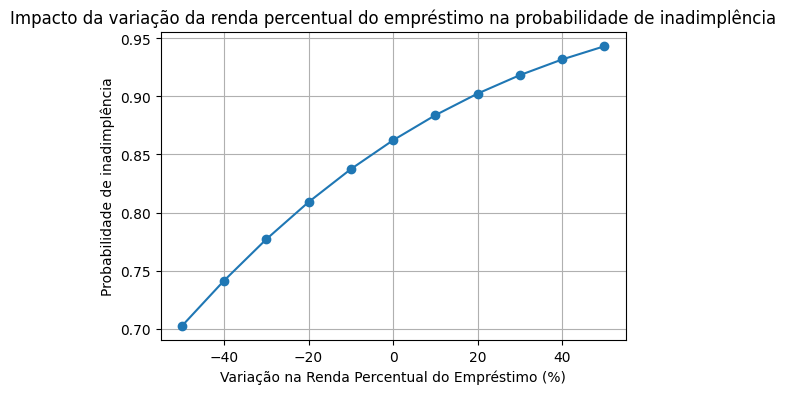

In [ ]:
# vamo fzr tbm uma análise de sensibilidade às variáveis de entrada pra entender o impacto de suas variações no desempenho do modelo
# como, entre as variáveis numéricas, a gente viu que a renda percentual do empréstimo é a que mais impacta no modelo, vamo fzr sobre ela

cliente_exemplo = X_teste.iloc [0].copy()  #-> aqi a gente pega um cliente específico
impacto_renda_percentual = []
variacoes_renda_percentual = np.arange (-0.5, 0.51, 0.1)  #-> percentuais de variação da renda percentual de -50% a +50%

for var in variacoes_renda_percentual:  #-> pra testar o impacto da mudança da renda percentual
    cliente_modificado = cliente_exemplo.copy()
    cliente_modificado['renda_percentual_do_empréstimo'] = cliente_modificado['renda_percentual_do_empréstimo'] * (1 + var)
    cliente_modificado_df = pd.DataFrame([cliente_modificado], columns=X_teste.columns)
    prob = pipeline.predict_proba(cliente_modificado_df)[:, 1][0]  #-> pra calcular a probabilidade de inadimplencia com a renda percentual modificada
    impacto_renda_percentual.append(prob)

plt.figure(figsize=(6, 4))
plt.plot(variacoes_renda_percentual * 100, impacto_renda_percentual, marker='o')
plt.xlabel('Variação na Renda Percentual do Empréstimo (%)')
plt.ylabel('Probabilidade de inadimplência')
plt.title('Impacto da variação da renda percentual do empréstimo na probabilidade de inadimplência')
plt.grid(True)
plt.show()


a intenção aqui é pegar um cliente específico no conjunto de teste e simular o que aconteceria com a probabilidade de inadimplencia dele se a renda percentual do empréstimo (que é a variável numérica com maior impacto no modelo) variasse de -50% a 50%, mantendo todas as outras variáveis iguais.
- o ponto central (0%) é a probabilidade real do cliente e, nesse caso, é algo próximo de 0.86 (86% de chance de default).

pela curva, a gente consegue concluir que:
- a relação entre a renda comprometida e a inadimplencia confirma o que os coeficientes já disseram antes: quanto maior a renda percentual, maior a probabilidade de inadimplencia;
- mesmo reduzindo a renda percentual em 50%, esse cliente ainda tem cerca de 70% de possibilidade de default, o que tbm confirma o óbvio: outras variáveis do perfil dele tbm contribuem pro risco alto;
- o formato da curva tbm é interessante. dá pra concluir que o impacto de aumentar a renda percentual vai diminuindo conforme ela já tá alta. ou seja: quando grande parte da renda já tá comprometida, comprometer só mais um pouquinho não vai alterar tanto o risco.

essa análise mostra o impacto de uma única variável pra um cliente específico. pra entender a contribuição de todas as variáveis simultaneamente pra cada previsão, a gente pode usar SHAP, que vai mostrar o impacto de cada variável para cada predição individual.

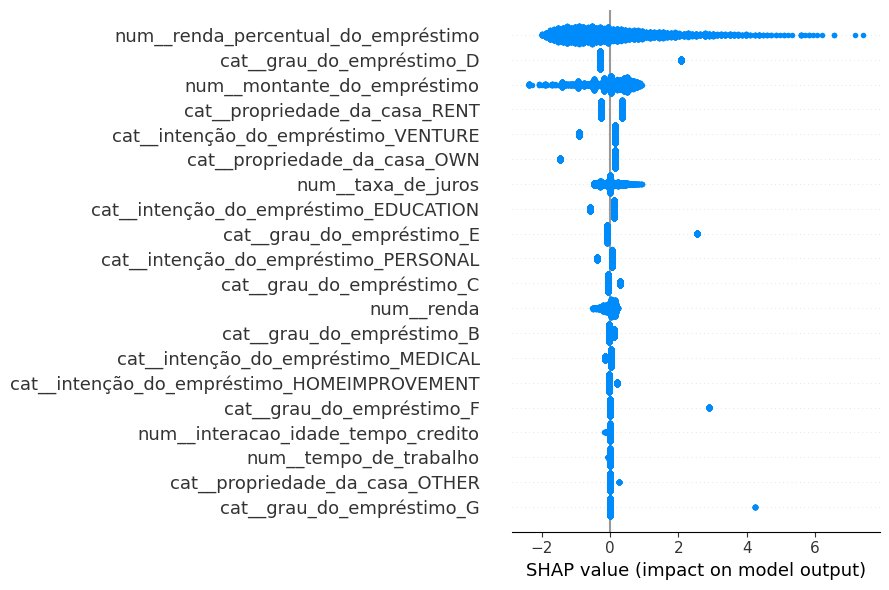

In [ ]:
# vamo usar SHAP pra decompor a previsão do modelo em contribuições individuais de cada feature pra cada cliente

import shap

explainer = shap.LinearExplainer(pipeline.named_steps['classifier'], pipeline.named_steps['preprocessor'].transform(X_treino))
shap_values = explainer.shap_values(pipeline.named_steps['preprocessor'].transform(X_teste))
shap.summary_plot(shap_values, feature_names=variaveis_pipeline, plot_size=(9, 6))


esse gráfico funciona de forma que: cada ponto é um cliente do conjunto de teste. a posição na horizontal mostra o quanto a variável em questão empurrou a previsão pra inadimplente (direita) ou adimplente (esquerda).

ele, basicamente, confirma e aprofunda o que os coeficientes mostraram:
- a renda percentual comprometida é o fator dominante na previsão individual;
- os graus de empréstimo aparecem espalhados ao longo do ranking, todos com impactos positivos relevantes, confirmando que graus mais altos de risco (D, E, F, G) aumentam a probabilidade de default.
- variáveis como interação idade-tempo-crédito e tempo de trabalho aparecem no final com SHAP values próximos de zero pra quase todos os clientes, sugerindo que poderiam ser removidas sem impacto significativo numa versão mais enxuta do modelo.


## Conclusões de Negócio

discutindo sobre a política da concessão de crédito e os resultados do modelo a gente pode fazer algumas análises:
- o modelo permite classificar clientes em grupos de risco com base nas variáveis mais impactantes (especialmente renda percentual comprometida e grau do empréstimo) permitindo que a instituição crie políticas diferenciadas pra cada segmento: clientes de baixo risco podem receber condições mais flexíveis e taxas menores, enquanto clientes de alto risco podem exigir garantias adicionais (como um fiador, por exemplo) ou termos mais restritivos;
- tentando diminuir a chance de perder bons clientes, a instituição poderia conceder crédito pra um cliente com risco moderado de inadimplencia, mas acompanhar o crédito de forma frequente, verificando periodicamente sua situação financeira e fazendo ajustes de cotrato conforme necessário;
- as instituições podem ter a liberdade de avaliar o limiar de decisão e escolher estratégicamente a melhor política de risco a ser seguida. enquanto instituições conservadoras podem operar com limiares menores, as instituições mais agressivas podem operar com limiares maiores.
— principais sinais de alerta: segundo o SHAP, os fatores que mais aumentam o risco individualmente são alta renda percentual comprometida, graus de empréstimo D-G e perfil de aluguel de imóvel. Esses fatores podem guiar regras de negócio complementares ao modelo, ou seja: além do score grado pelo modelo, a instituição pode criar critérios automáticos baseados nas variáveis mais impactantes que funcionariam como filtros adicionais (como recusar automaticamente clientes que comprometem mais de 40% da renda com o empréstimo, independente do score do modelo, por exemplo);
- no fim das contas, toda tomada de decisão vai precisar levar em conta a estratégia de risco que a instituição financeira tá disposta a correr.